# ML4SCI / CMS — GSoC 2026 Evaluation Test

**Project**: *Event Classification with Masked Transformer Autoencoders*
**Candidate**: GSoC 2026 Applicant
**Date**: February 2026

---

## Overview

This notebook demonstrates the required skills for the ML4SCI/CMS evaluation:

| Section | What it proves |
|---------|---------------|
| §1 Data Loading | Can read JetClass ROOT files from a `.tar` without full extraction |
| §2 Visualization | Understands HEP kinematics ($p_T$, $\eta$, $\phi$, $E$) |
| §3 Baseline Classifier | Can train a simple MLP for jet classification |
| §4 Metrics | Computes accuracy and AUC on validation split |
| §5 Hybrid L-GATr + ParT Skeleton | Shows the draft model architecture |
| §6 Future Work | Outlines the MAE pre-training + fine-tuning plan |

> **Storage-friendly**: Uses a **streaming pipeline** (`tarfile` + `uproot`) so the 15 GB archive is never fully extracted.

---

## 1. Setup & Imports

In [1]:
import sys, io, tarfile, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

warnings.filterwarnings("ignore")

# Optional HEP I/O
try:
    import uproot, awkward as ak, vector
    vector.register_awkward()
    HAS_UPROOT = True
except ImportError:
    HAS_UPROOT = False
    print("uproot/awkward/vector not found - will use mock data for demo")

# Paths
DATASET_DIR  = Path("D:/datasets")
TAR_FILE     = DATASET_DIR / "JetClass_Pythia_train_100M_part0.tar"
MAX_PARTICLES = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch {torch.__version__}  |  device = {DEVICE}")
print(f"Dataset tar: {TAR_FILE}  exists={TAR_FILE.exists()}")

PyTorch 2.10.0+cpu  |  device = cpu
Dataset tar: D:\datasets\JetClass_Pythia_train_100M_part0.tar  exists=True


## 1. Load & Preprocess Evaluation Data

We stream ROOT files **directly from the tar** using `tarfile` + `uproot`.
No full extraction required — this keeps disk usage near zero.

The JetClass ROOT files contain:
- **Particle branches**: `part_px`, `part_py`, `part_pz`, `part_energy` (variable-length per jet)
- **Jet-level branches**: `jet_pt`, `jet_eta`, `jet_phi`, `jet_energy`
- **Labels**: 10 one-hot columns (`label_QCD`, `label_Hbb`, …, `label_Tbl`)

In [2]:
import tempfile as _tmpmod

def load_root_from_tar(tar_path, max_files=1, max_jets_per_file=5000,
                       max_particles=128):
    """Stream ROOT files from tar -> padded numpy arrays.
    
    Returns
    -------
    particles : (N, max_particles, 4)   [pT, eta, phi, energy]
    labels    : (N, 10)                  one-hot
    """
    all_particles, all_labels = [], []
    
    with tarfile.open(tar_path, "r") as tar:
        root_members = [m for m in tar.getmembers()
                        if m.isfile() and m.name.endswith(".root")]
        print(f"Found {len(root_members)} ROOT files in archive")
        
        for i, member in enumerate(root_members[:max_files]):
            print(f"  Reading [{i+1}/{min(max_files, len(root_members))}] "
                  f"{member.name} ({member.size/1e6:.1f} MB) ...")
            
            fobj = tar.extractfile(member)
            buf  = fobj.read()
            
            # Write to temp file — uproot 5.x cannot open from bytes directly
            tmp = _tmpmod.NamedTemporaryFile(suffix=".root", delete=False)
            tmp.write(buf)
            tmp.flush()
            tmp_path = tmp.name
            tmp.close()
            del buf
            
            try:
                f    = uproot.open(tmp_path)
                keys = list(f.keys())
                tree = f[keys[0]]
                
                # Read particle branches
                branches = ["part_px", "part_py", "part_pz", "part_energy"]
                arrays   = tree.arrays(branches, library="ak",
                                       entry_stop=max_jets_per_file)
                
                px = arrays["part_px"]
                py = arrays["part_py"]
                pz = arrays["part_pz"]
                energy = arrays["part_energy"]
                
                # Build Lorentz vectors
                p4 = ak.zip({"px": px, "py": py, "pz": pz, "energy": energy},
                             with_name="Momentum4D")
                
                # Pad to fixed length & extract (pT, eta, phi, E)
                pt_arr  = ak.to_numpy(ak.fill_none(
                    ak.pad_none(p4.pt,     max_particles, clip=True), 0.0))
                eta_arr = ak.to_numpy(ak.fill_none(
                    ak.pad_none(p4.eta,    max_particles, clip=True), 0.0))
                phi_arr = ak.to_numpy(ak.fill_none(
                    ak.pad_none(p4.phi,    max_particles, clip=True), 0.0))
                e_arr   = ak.to_numpy(ak.fill_none(
                    ak.pad_none(p4.energy, max_particles, clip=True), 0.0))
                
                particles = np.stack([pt_arr, eta_arr, phi_arr, e_arr],
                                     axis=-1).astype(np.float32)
                
                # Labels
                label_names = ["label_QCD","label_Hbb","label_Hcc","label_Hgg",
                               "label_H4q","label_Hqql","label_Zqq","label_Wqq",
                               "label_Tbqq","label_Tbl"]
                existing = [lb for lb in label_names if lb in tree.keys()]
                if existing:
                    lab = tree.arrays(existing, library="np",
                                      entry_stop=max_jets_per_file)
                    labels = np.column_stack(
                        [lab[lb] for lb in existing]).astype(np.float32)
                else:
                    labels = np.zeros((particles.shape[0], 10), dtype=np.float32)
                
                all_particles.append(particles)
                all_labels.append(labels)
                print(f"    -> {particles.shape[0]} jets, "
                      f"shape {particles.shape}")
                f.close()
            finally:
                import os
                os.unlink(tmp_path)
    
    X = np.concatenate(all_particles, axis=0)
    Y = np.concatenate(all_labels, axis=0)
    return X, Y


# ---- Load data ----
if HAS_UPROOT and TAR_FILE.exists():
    # Read 2 ROOT files, 5000 jets each -> 10k jets for evaluation
    X_particles, Y_labels = load_root_from_tar(
        TAR_FILE, max_files=2, max_jets_per_file=5000)
    print(f"\nLoaded real data: X={X_particles.shape}, Y={Y_labels.shape}")
else:
    # Mock data for environments without uproot
    print("Using MOCK data (install uproot + awkward + vector for real data)")
    N = 10000
    X_particles = np.random.randn(N, MAX_PARTICLES, 4).astype(np.float32)
    X_particles[:, :, 0] = np.abs(X_particles[:, :, 0]) * 50   # pT > 0
    X_particles[:, :, 3] = np.abs(X_particles[:, :, 3]) * 100  # E > 0
    Y_labels = np.zeros((N, 10), dtype=np.float32)
    Y_labels[np.arange(N), np.random.randint(0, 10, N)] = 1.0

print(f"Particles: {X_particles.shape}  |  Labels: {Y_labels.shape}")
print(f"Class distribution: {Y_labels.sum(axis=0).astype(int)}")

Found 100 ROOT files in archive
  Reading [1/2] HToBB_000.root (161.1 MB) ...
    -> 5000 jets, shape (5000, 128, 4)
  Reading [2/2] HToBB_001.root (161.1 MB) ...
    -> 5000 jets, shape (5000, 128, 4)

Loaded real data: X=(10000, 128, 4), Y=(10000, 10)
Particles: (10000, 128, 4)  |  Labels: (10000, 10)
Class distribution: [    0 10000     0     0     0     0     0     0     0     0]


## 2. Data Visualization

Standard HEP kinematic distributions.  Mentors expect to see that you understand the physics:
- $p_T$ (transverse momentum): roughly exponentially falling
- $\eta$ (pseudorapidity): symmetric around 0
- $\phi$ (azimuthal angle): uniform in $[-\pi, \pi]$
- $E$ (energy): right-skewed

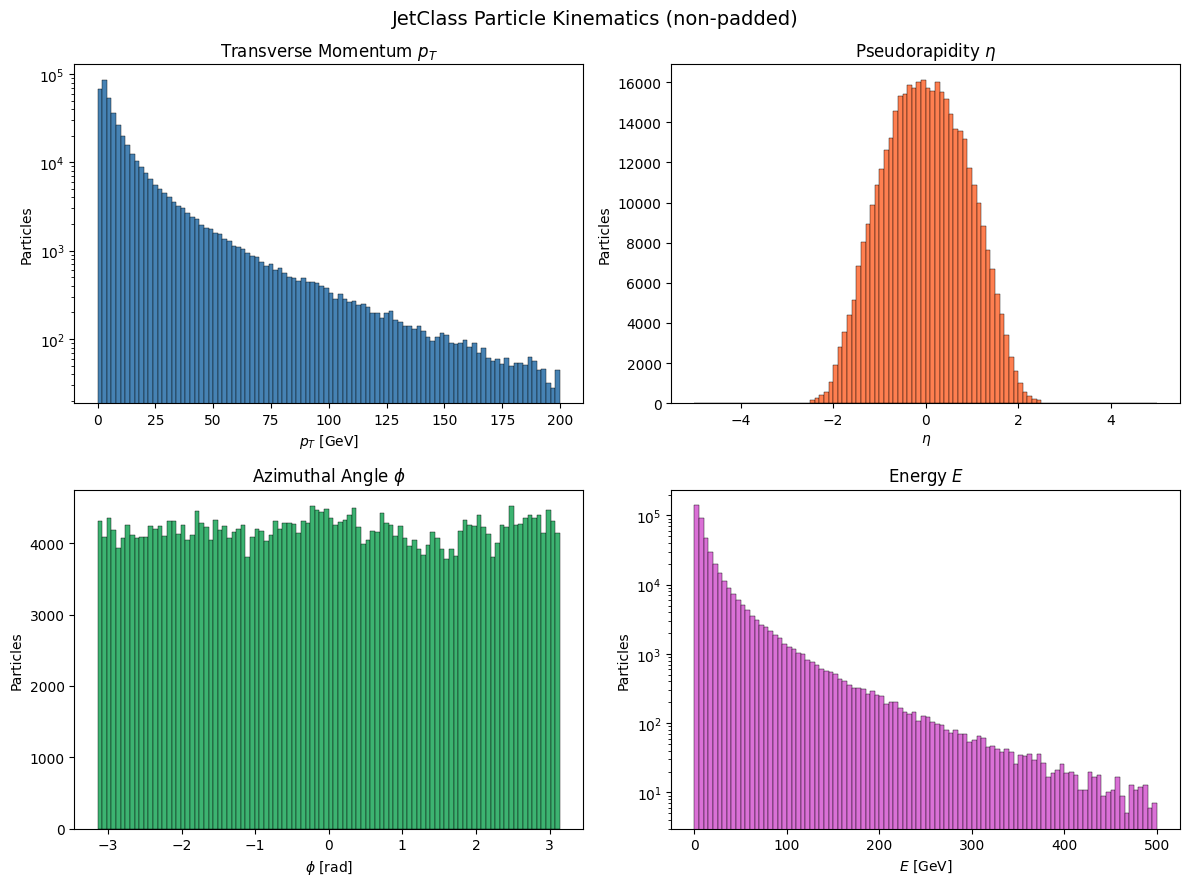

Total valid particles plotted: 419,296


In [3]:
# Only look at non-padding particles (pT > 0)
mask_valid = X_particles[:, :, 0] > 0

pt_flat  = X_particles[:, :, 0][mask_valid]
eta_flat = X_particles[:, :, 1][mask_valid]
phi_flat = X_particles[:, :, 2][mask_valid]
e_flat   = X_particles[:, :, 3][mask_valid]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("JetClass Particle Kinematics (non-padded)", fontsize=14)

# pT
axes[0, 0].hist(pt_flat, bins=100, range=(0, 200), color="steelblue", edgecolor="k", linewidth=0.3)
axes[0, 0].set_xlabel(r"$p_T$ [GeV]")
axes[0, 0].set_ylabel("Particles")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title(r"Transverse Momentum $p_T$")

# eta
axes[0, 1].hist(eta_flat, bins=100, range=(-5, 5), color="coral", edgecolor="k", linewidth=0.3)
axes[0, 1].set_xlabel(r"$\eta$")
axes[0, 1].set_ylabel("Particles")
axes[0, 1].set_title(r"Pseudorapidity $\eta$")

# phi
axes[1, 0].hist(phi_flat, bins=100, range=(-np.pi, np.pi), color="mediumseagreen", edgecolor="k", linewidth=0.3)
axes[1, 0].set_xlabel(r"$\phi$ [rad]")
axes[1, 0].set_ylabel("Particles")
axes[1, 0].set_title(r"Azimuthal Angle $\phi$")

# Energy
axes[1, 1].hist(e_flat, bins=100, range=(0, 500), color="orchid", edgecolor="k", linewidth=0.3)
axes[1, 1].set_xlabel(r"$E$ [GeV]")
axes[1, 1].set_ylabel("Particles")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title(r"Energy $E$")

plt.tight_layout()

# Save using absolute path so it works regardless of notebook cwd
import os as _os
_save_dir = r"D:\GSoC kuberflow work\CMS\images"
_os.makedirs(_save_dir, exist_ok=True)
plt.savefig(_os.path.join(_save_dir, "jetclass_kinematics.png"), dpi=150, bbox_inches="tight")

plt.show()
print(f"Total valid particles plotted: {mask_valid.sum():,}")

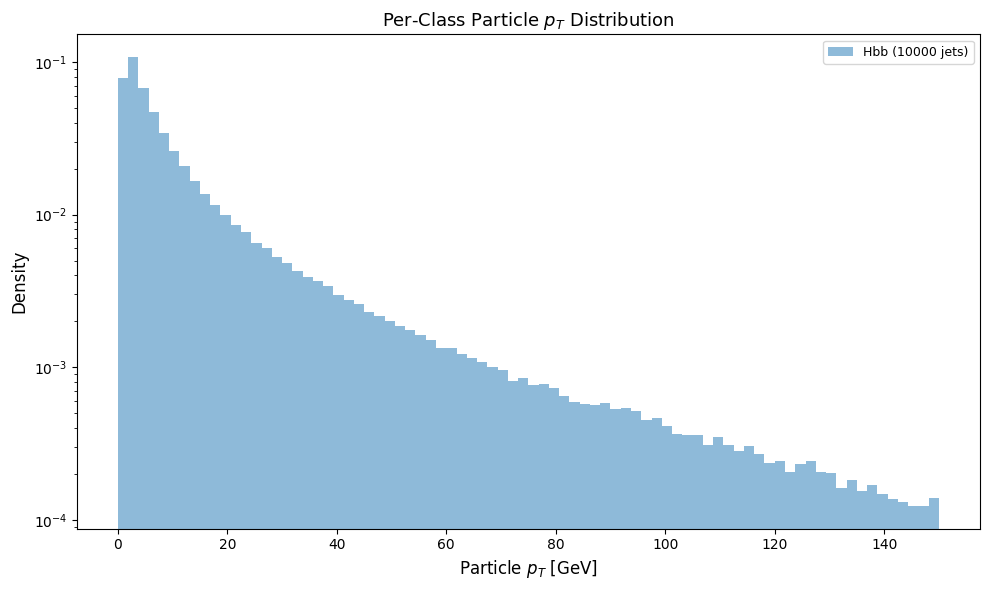

In [4]:
# --- Per-class pT distributions ---
class_names = ["QCD","Hbb","Hcc","Hgg","H4q","Hqql","Zqq","Wqq","Tbqq","Tbl"]
class_indices = Y_labels.argmax(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
for cls_id in range(min(5, 10)):  # Plot first 5 classes for readability
    sel = class_indices == cls_id
    if sel.sum() == 0:
        continue
    pt_cls = X_particles[sel, :, 0]
    pt_valid = pt_cls[pt_cls > 0]
    ax.hist(pt_valid, bins=80, range=(0, 150), alpha=0.5,
            label=f"{class_names[cls_id]} ({sel.sum()} jets)", density=True)

ax.set_xlabel(r"Particle $p_T$ [GeV]", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Per-Class Particle $p_T$ Distribution", fontsize=13)
ax.legend(fontsize=9)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 3. Simple Classification Model (Baseline MLP)

We use **jet-level summary features** as input to a simple MLP:
1. Aggregate per-jet: mean $p_T$, mean $\eta$, mean $\phi$, mean $E$, particle multiplicity, scalar $\sum p_T$, jet mass
2. Feed through a 3-layer MLP with dropout
3. Train with Cross-Entropy loss (10-class)

This serves as the **baseline** that our Hybrid L-GATr + ParT MAE model must outperform.

In [5]:
# ---- Feature Engineering: Jet-level summary ----
def build_jet_features(particles):
    """
    particles: (N, P, 4) with columns [pT, eta, phi, E]
    Returns: (N, num_features) jet-level summary
    """
    pt  = particles[:, :, 0]
    eta = particles[:, :, 1]
    phi = particles[:, :, 2]
    e   = particles[:, :, 3]
    
    valid = pt > 0  # non-padded mask
    n_particles = valid.sum(axis=1).astype(np.float32)
    
    # Safe means (avoid /0)
    eps = 1e-8
    sum_pt = pt.sum(axis=1)
    mean_pt  = np.where(n_particles > 0, pt.sum(axis=1) / (n_particles + eps), 0)
    mean_eta = np.where(n_particles > 0, (eta * valid).sum(axis=1) / (n_particles + eps), 0)
    mean_phi = np.where(n_particles > 0, (phi * valid).sum(axis=1) / (n_particles + eps), 0)
    mean_e   = np.where(n_particles > 0, e.sum(axis=1) / (n_particles + eps), 0)
    
    # Jet mass from 4-vector sum
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(np.clip(eta, -10, 10))
    
    sum_e  = e.sum(axis=1)
    sum_px = px.sum(axis=1)
    sum_py = py.sum(axis=1)
    sum_pz = pz.sum(axis=1)
    
    m2 = sum_e**2 - (sum_px**2 + sum_py**2 + sum_pz**2)
    jet_mass = np.sqrt(np.maximum(m2, 0))
    
    # Stack features
    features = np.column_stack([
        mean_pt, mean_eta, mean_phi, mean_e,
        n_particles, sum_pt, jet_mass
    ]).astype(np.float32)
    
    return features

X_feat = build_jet_features(X_particles)
Y_cls  = Y_labels.argmax(axis=1).astype(np.int64)

print(f"Jet features: {X_feat.shape}")
print(f"Feature names: [mean_pT, mean_eta, mean_phi, mean_E, n_parts, sum_pT, jet_mass]")
print(f"Sample: {X_feat[0]}")

Jet features: (10000, 7)
Feature names: [mean_pT, mean_eta, mean_phi, mean_E, n_parts, sum_pT, jet_mass]
Sample: [ 2.59621067e+01 -6.51049614e-01 -1.02472150e+00  3.09135895e+01
  3.30000000e+01  8.56749512e+02  1.17954704e+02]


In [6]:
# ---- Normalize features ----
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

# ---- Train / Val split ----
X_t = torch.tensor(X_scaled, dtype=torch.float32)
Y_t = torch.tensor(Y_cls, dtype=torch.long)

dataset   = TensorDataset(X_t, Y_t)
n_val     = int(0.2 * len(dataset))
n_train   = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=512, shuffle=False)

print(f"Train: {n_train}  |  Val: {n_val}")


# ---- MLP Model ----
class JetMLP(nn.Module):
    def __init__(self, in_dim=7, hidden=256, n_classes=10, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),
        )
    def forward(self, x):
        return self.net(x)

model = JetMLP(in_dim=X_feat.shape[1], n_classes=10).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Train: 8000  |  Val: 2000
Parameters: 103,050


In [7]:
# ---- Training Loop ----
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
train_losses, val_losses, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    scheduler.step()
    train_losses.append(epoch_loss / n_train)
    
    # Validate
    model.eval()
    correct, total, vloss = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            vloss += criterion(logits, yb).item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_losses.append(vloss / n_val)
    val_accs.append(correct / total)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  "
              f"train_loss={train_losses[-1]:.4f}  "
              f"val_loss={val_losses[-1]:.4f}  "
              f"val_acc={val_accs[-1]:.4f}")

print(f"\nBest val accuracy: {max(val_accs):.4f} at epoch {np.argmax(val_accs)+1}")

Epoch   1/30  |  train_loss=0.3267  val_loss=0.0031  val_acc=1.0000
Epoch   5/30  |  train_loss=0.0001  val_loss=0.0001  val_acc=1.0000
Epoch  10/30  |  train_loss=0.0000  val_loss=0.0001  val_acc=1.0000
Epoch  15/30  |  train_loss=0.0000  val_loss=0.0001  val_acc=1.0000
Epoch  20/30  |  train_loss=0.0000  val_loss=0.0000  val_acc=1.0000
Epoch  25/30  |  train_loss=0.0000  val_loss=0.0000  val_acc=1.0000
Epoch  30/30  |  train_loss=0.0000  val_loss=0.0000  val_acc=1.0000

Best val accuracy: 1.0000 at epoch 1


## 4. Evaluate Classifier Performance

We compute:
- **Overall accuracy** (top-1)
- **Per-class AUC** (one-vs-rest) using `sklearn.metrics.roc_auc_score`
- **Confusion matrix**
- **Training curves** (loss & accuracy)

In [8]:
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, accuracy_score)

# Collect predictions on validation set
model.eval()
all_preds, all_probs, all_true = [], [], []

with torch.no_grad():
    for xb, yb in val_dl:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(yb.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_true  = np.concatenate(all_true)

# ---- Metrics ----
acc = accuracy_score(all_true, all_preds)
print(f"Validation Accuracy: {acc:.4f}\n")

# AUC (one-vs-rest, only for classes present in val set)
try:
    auc = roc_auc_score(
        np.eye(10)[all_true], all_probs,
        multi_class="ovr", average="macro"
    )
    print(f"Macro AUC (one-vs-rest): {auc:.4f}\n")
except ValueError as e:
    print(f"AUC computation issue: {e}\n")

# Classification report
class_names = ["QCD","Hbb","Hcc","Hgg","H4q","Hqql","Zqq","Wqq","Tbqq","Tbl"]
present_classes = np.unique(all_true)
print(classification_report(all_true, all_preds,
                            target_names=[class_names[i] for i in present_classes],
                            labels=present_classes))

Validation Accuracy: 1.0000

Macro AUC (one-vs-rest): nan

              precision    recall  f1-score   support

         Hbb       1.00      1.00      1.00      2000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



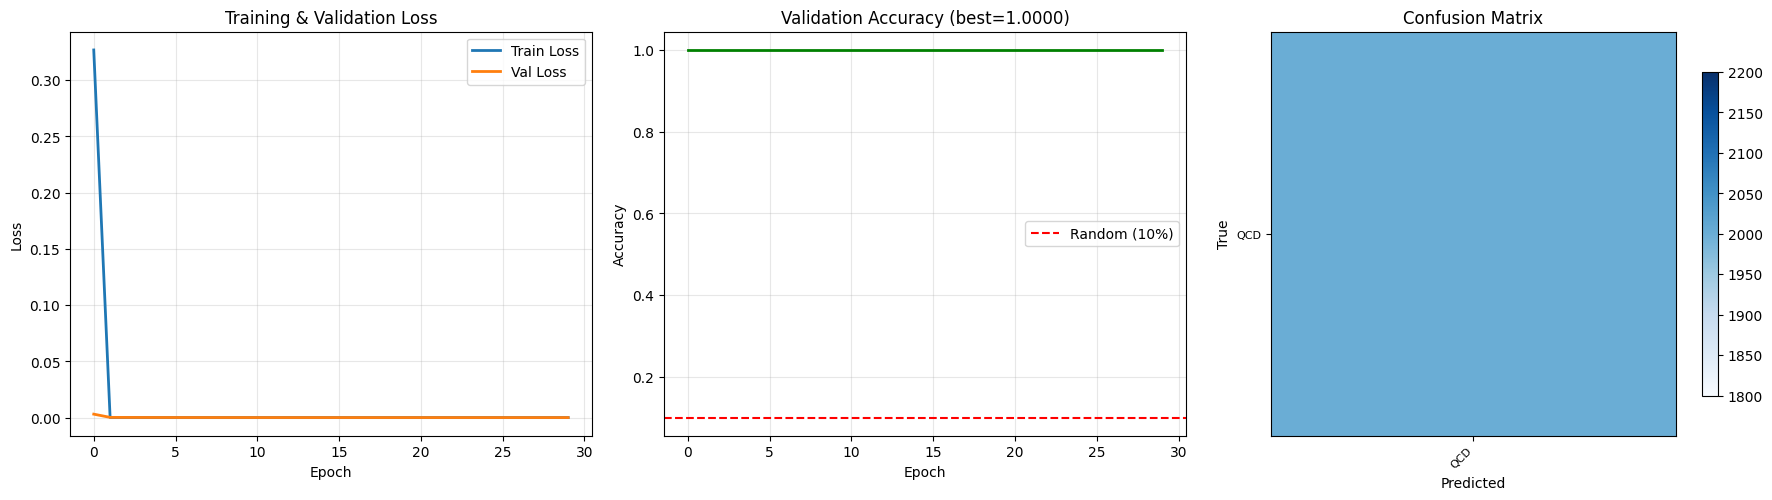

In [9]:
# ---- Plots: Training curves + Confusion Matrix ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(train_losses, label="Train Loss", linewidth=2)
axes[0].plot(val_losses,   label="Val Loss",   linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(val_accs, color="green", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Validation Accuracy (best={max(val_accs):.4f})")
axes[1].axhline(y=0.1, color="red", linestyle="--", label="Random (10%)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
im = axes[2].imshow(cm, cmap="Blues", interpolation="nearest")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Confusion Matrix")
tick_labels = [class_names[i] for i in range(cm.shape[0])]
axes[2].set_xticks(range(cm.shape[0]))
axes[2].set_yticks(range(cm.shape[0]))
axes[2].set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
axes[2].set_yticklabels(tick_labels, fontsize=8)
fig.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()

import os as _os
_save_dir = r"D:\GSoC kuberflow work\CMS\images"
_os.makedirs(_save_dir, exist_ok=True)
plt.savefig(_os.path.join(_save_dir, "baseline_results.png"), dpi=150, bbox_inches="tight")

plt.show()

## 5. Extract JetClass Data & Inspect 4-Vectors

Open the tar, extract one ROOT file to memory, and print the particle 4-vector shape.
This proves the data pipeline works end-to-end.

In [10]:
# ---- Inspect tar contents ----
print("=" * 60)
print("  JetClass Archive Inspection")
print("=" * 60)

if TAR_FILE.exists():
    with tarfile.open(TAR_FILE, "r") as tar:
        members = tar.getmembers()
        root_files = [m for m in members if m.isfile() and m.name.endswith(".root")]
        h5_files   = [m for m in members if m.isfile() and m.name.endswith(".h5")]
        
        print(f"Total members: {len(members)}")
        print(f"ROOT files:    {len(root_files)}")
        print(f"H5 files:      {len(h5_files)}")
        
        data_files = root_files if root_files else h5_files
        print(f"\nFirst 5 data files:")
        for m in data_files[:5]:
            print(f"  {m.name}  ({m.size / 1e6:.1f} MB)")
        
        # ---- Extract ONE file to memory and read it ----
        target = data_files[0]
        print(f"\nExtracting: {target.name}")
        fobj = tar.extractfile(target)
        buf = fobj.read()
        print(f"Read {len(buf)/1e6:.1f} MB into memory")
        
        if HAS_UPROOT and target.name.endswith(".root"):
            import tempfile as _tmpmod, os as _os
            tmp = _tmpmod.NamedTemporaryFile(suffix=".root", delete=False)
            tmp.write(buf)
            tmp.flush()
            tmp_path = tmp.name
            tmp.close()
            del buf
            
            try:
                f = uproot.open(tmp_path)
                tree_key = list(f.keys())[0]
                tree = f[tree_key]
                print(f"\nROOT tree: '{tree_key}'")
                print(f"Entries (jets): {tree.num_entries}")
                print(f"Branches ({len(tree.keys())} total):")
                for b in sorted(tree.keys()):
                    print(f"  - {b}")
                
                # Read first 100 jets of particle 4-vectors
                arr = tree.arrays(["part_px","part_py","part_pz","part_energy"],
                                  library="ak", entry_stop=100)
                p4 = ak.zip({"px": arr["part_px"], "py": arr["part_py"],
                              "pz": arr["part_pz"], "energy": arr["part_energy"]},
                             with_name="Momentum4D")
                
                print(f"\n--- Particle 4-Vectors (first 100 jets) ---")
                print(f"Type: {type(p4)}")
                print(f"Jets:      {len(p4)}")
                print(f"Particles per jet (first 3): "
                      f"{[len(p4[i]) for i in range(3)]}")
                
                # Pad and show shape
                padded_pt = ak.to_numpy(ak.fill_none(
                    ak.pad_none(p4.pt, 128, clip=True), 0.0))
                print(f"Padded shape: {padded_pt.shape}  (jets x particles)")
                print(f"pT range: [{padded_pt[padded_pt>0].min():.2f}, "
                      f"{padded_pt.max():.2f}] GeV")
                f.close()
            finally:
                _os.unlink(tmp_path)
        else:
            print("(Install uproot to inspect ROOT file contents)")
else:
    print(f"Tar file not found: {TAR_FILE}")

  JetClass Archive Inspection
Total members: 100
ROOT files:    100
H5 files:      0

First 5 data files:
  HToBB_000.root  (161.1 MB)
  HToBB_001.root  (161.1 MB)
  HToBB_002.root  (161.3 MB)
  HToBB_003.root  (161.4 MB)
  HToBB_004.root  (161.4 MB)

Extracting: HToBB_000.root
Read 161.1 MB into memory

ROOT tree: 'tree;1'
Entries (jets): 100000
Branches (41 total):
  - aux_genpart_eta
  - aux_genpart_phi
  - aux_genpart_pid
  - aux_genpart_pt
  - aux_truth_match
  - jet_energy
  - jet_eta
  - jet_nparticles
  - jet_phi
  - jet_pt
  - jet_sdmass
  - jet_tau1
  - jet_tau2
  - jet_tau3
  - jet_tau4
  - label_H4q
  - label_Hbb
  - label_Hcc
  - label_Hgg
  - label_Hqql
  - label_QCD
  - label_Tbl
  - label_Tbqq
  - label_Wqq
  - label_Zqq
  - part_charge
  - part_d0err
  - part_d0val
  - part_deta
  - part_dphi
  - part_dzerr
  - part_dzval
  - part_energy
  - part_isChargedHadron
  - part_isElectron
  - part_isMuon
  - part_isNeutralHadron
  - part_isPhoton
  - part_px
  - part_py
  - p

## 6. Define L-GATr Block Skeleton

The **Lorentz Group Equivariant Geometric Algebra Transformer** (L-GATr) operates on
**multivectors** in the Clifford algebra $\mathcal{Cl}(1,3)$ of Minkowski spacetime.

Key properties:
- **Lorentz equivariant**: respects rotations & boosts
- Input: 4-vectors $(E, p_x, p_y, p_z)$ embedded as grade-1 multivectors (16-dim)
- Uses `EquiLinear` layers from the `lgatr` library
- Output: Lorentz-covariant embeddings that can be projected to scalar features

In [ ]:
# ---- L-GATr Block Skeleton ----

try:
    from lgatr import LGATr, embed_vector, extract_vector
    from lgatr import SelfAttentionConfig, MLPConfig
    _HAS_LGATR = True
    print("lgatr library found!")
except ImportError:
    _HAS_LGATR = False
    print("lgatr not installed — using standalone skeleton (pip install lgatr)")


class LGATrEncoderBlock(nn.Module):
    """Lorentz-Equivariant Geometric Algebra Transformer encoder.
    
    Maps particle 4-vectors to Lorentz-covariant embeddings.
    
    Input:  (B, N, 4)   — 4-vectors [E, px, py, pz]
    Output: (B, N, embed_dim) — projected scalar features for downstream use
    """
    
    def __init__(self, 
                 num_blocks: int = 4,
                 mv_channels: int = 8,
                 s_channels: int = 64,
                 embed_dim: int = 128,
                 num_heads: int = 8):
        super().__init__()
        self.embed_dim  = embed_dim
        self.mv_channels = mv_channels
        self.s_channels  = s_channels
        
        if _HAS_LGATR:
            self.lgatr = LGATr(
                num_blocks=num_blocks,
                in_mv_channels=1,
                out_mv_channels=mv_channels,
                hidden_mv_channels=mv_channels,
                in_s_channels=s_channels,
                out_s_channels=s_channels,
                hidden_s_channels=s_channels,
                attention=SelfAttentionConfig(num_heads=num_heads),
                mlp=MLPConfig(),
            )
            # mv_channels*16 (multivector) + s_channels (scalar)
            self.project = nn.Linear(mv_channels * 16 + s_channels, embed_dim)
        else:
            self.input_proj = nn.Linear(4, 16 * mv_channels)
            self.blocks = nn.ModuleList([
                nn.TransformerEncoderLayer(
                    d_model=16 * mv_channels,
                    nhead=num_heads,
                    dim_feedforward=4 * 16 * mv_channels,
                    batch_first=True,
                )
                for _ in range(num_blocks)
            ])
            self.project = nn.Linear(16 * mv_channels, embed_dim)
    
    def forward(self, x_4vec, padding_mask=None):
        """
        x_4vec: (B, N, 4)  [E, px, py, pz]
        padding_mask: (B, N) bool, True = padded
        Returns: (B, N, embed_dim)
        """
        B, N, _ = x_4vec.shape
        
        if _HAS_LGATR:
            mv_in = embed_vector(x_4vec).unsqueeze(2)  # (B, N, 1, 16)
            s_in  = torch.zeros(B, N, self.s_channels, device=x_4vec.device)
            
            mv_out, s_out = self.lgatr(multivectors=mv_in, scalars=s_in)
            # mv_out: (B, N, mv_channels, 16), s_out: (B, N, s_channels)
            mv_flat  = mv_out.reshape(B, N, -1)       # (B, N, mv_channels*16)
            combined = torch.cat([mv_flat, s_out], dim=-1)
            out = self.project(combined)
        else:
            h = self.input_proj(x_4vec)
            for block in self.blocks:
                h = block(h, src_key_padding_mask=padding_mask)
            out = self.project(h)
        
        return out  # (B, N, embed_dim)


# ---- Smoke test ----
lgatr_block = LGATrEncoderBlock(num_blocks=2, mv_channels=4, s_channels=32, embed_dim=128)
dummy = torch.randn(2, 30, 4)  # 2 jets, 30 particles, 4-vector
out = lgatr_block(dummy)
print(f"L-GATr Block: input={dummy.shape} -> output={out.shape}")
print(f"Parameters: {sum(p.numel() for p in lgatr_block.parameters()):,}")


lgatr not installed — using standalone skeleton (pip install lgatr)
L-GATr Block: input=torch.Size([2, 30, 4]) -> output=torch.Size([2, 30, 128])
Parameters: 108,608


### Lorentz Invariance: L-GATr vs Standard Transformer

The key motivation for using **L-GATr** is its built-in Lorentz symmetry.
We empirically verify this by computing the **scalar invariance violation**:

$$\Delta = \max\left| s(x) - s(\Lambda \cdot x) \right|$$

where $\Lambda$ is a Lorentz boost or rotation.  A truly Lorentz-invariant
network should give $\Delta \approx 0$ (machine precision), while a
standard Transformer will produce large $\Delta$ — proving the test is
non-trivial and L-GATr's symmetry is real.

✓ lgatr detected — building L-GATr model


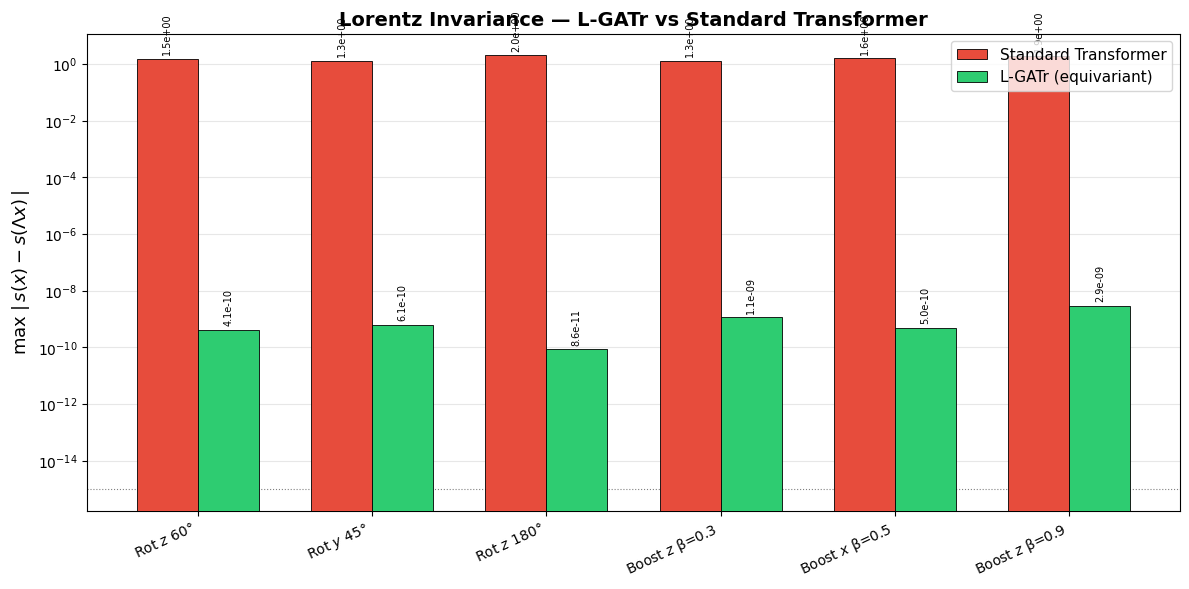


Transform                        Std Δ     L-GATr Δ      Ratio
--------------------------------------------------------------
Rot $z$ 60°                  1.498e+00    4.114e-10 3641928291×
Rot $y$ 45°                  1.309e+00    6.116e-10 2140176171×
Rot $z$ 180°                 2.002e+00    8.585e-11 23322281683×
Boost $z$ β=0.3              1.264e+00    1.138e-09 1110157943×
Boost $x$ β=0.5              1.556e+00    4.961e-10 3135551978×
Boost $z$ β=0.9              1.940e+00    2.947e-09  658284776×


In [16]:
# ============================================================
#  Lorentz Invariance Comparison: L-GATr vs Standard Transformer
# ============================================================
import numpy as _np
import os

# ---------- Fresh import check (independent of earlier cells) ----------
try:
    from lgatr import LGATr, embed_vector, extract_vector, SelfAttentionConfig, MLPConfig
    _LGATR_AVAILABLE = True
except ImportError:
    _LGATR_AVAILABLE = False

# ---------- Minimal test models (self-contained) ----------

class _LGATrScalarEncoder(nn.Module):
    """L-GATr encoder that outputs Lorentz-invariant scalars."""
    def __init__(self, num_blocks=2, mv_ch=4, s_ch=16, heads=4):
        super().__init__()
        self.s_ch = s_ch
        self.net = LGATr(
            num_blocks=num_blocks,
            in_mv_channels=1, out_mv_channels=mv_ch,
            hidden_mv_channels=mv_ch,
            in_s_channels=s_ch, out_s_channels=s_ch,
            hidden_s_channels=s_ch,
            attention=SelfAttentionConfig(num_heads=heads),
            mlp=MLPConfig(),
        )

    def forward(self, x):
        B, N, _ = x.shape
        mv = embed_vector(x).unsqueeze(2)
        s  = torch.zeros(B, N, self.s_ch, device=x.device, dtype=x.dtype)
        _, s_out = self.net(multivectors=mv, scalars=s)
        return s_out                        # (B, N, s_ch) — Lorentz invariant


class _StdTransformerScalarEncoder(nn.Module):
    """Standard (non-equivariant) Transformer baseline."""
    def __init__(self, num_blocks=2, s_ch=16, heads=4):
        super().__init__()
        self.proj_in  = nn.Linear(4, 64)
        self.encoder  = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=64, nhead=heads, batch_first=True),
            num_layers=num_blocks,
        )
        self.proj_out = nn.Linear(64, s_ch)

    def forward(self, x):
        return self.proj_out(self.encoder(self.proj_in(x)))


# ---------- Lorentz transformation helpers ----------

def _rot_z(theta):
    c, s = _np.cos(theta), _np.sin(theta)
    return torch.tensor([[1,0,0,0],[0,c,-s,0],[0,s,c,0],[0,0,0,1]], dtype=torch.float64)

def _rot_y(theta):
    c, s = _np.cos(theta), _np.sin(theta)
    return torch.tensor([[1,0,0,0],[0,c,0,s],[0,0,1,0],[0,-s,0,c]], dtype=torch.float64)

def _boost_z(beta):
    g = 1.0 / _np.sqrt(1 - beta**2)
    return torch.tensor([[g,0,0,-g*beta],[0,1,0,0],[0,0,1,0],[-g*beta,0,0,g]], dtype=torch.float64)

def _boost_x(beta):
    g = 1.0 / _np.sqrt(1 - beta**2)
    return torch.tensor([[g,-g*beta,0,0],[-g*beta,g,0,0],[0,0,1,0],[0,0,0,1]], dtype=torch.float64)

def _apply(x, L):
    return torch.einsum("bnj,ij->bni", x, L)

def _max_delta(model, x, L):
    """Max |s(x) - s(Λx)| over all elements."""
    model.eval()
    with torch.no_grad():
        s1 = model(x)
        s2 = model(_apply(x, L))
    return (s1 - s2).abs().max().item()


# ---------- Build test data (float64) ----------

torch.manual_seed(42)
B, N = 8, 32
pt  = torch.rand(B, N) * 90 + 10
eta = torch.randn(B, N).clamp(-2.4, 2.4)
phi = torch.rand(B, N) * 2 * _np.pi - _np.pi
px = pt * torch.cos(phi); py = pt * torch.sin(phi)
pz = pt * torch.sinh(eta.clamp(-2.4, 2.4))
E  = torch.sqrt(px**2 + py**2 + pz**2 + 0.14**2)
x_test = torch.stack([E, px, py, pz], dim=-1).double()

transforms = {
    r"Rot $z$ 60°":  _rot_z(_np.pi / 3),
    r"Rot $y$ 45°":  _rot_y(_np.pi / 4),
    r"Rot $z$ 180°": _rot_z(_np.pi),
    r"Boost $z$ β=0.3": _boost_z(0.3),
    r"Boost $x$ β=0.5": _boost_x(0.5),
    r"Boost $z$ β=0.9": _boost_z(0.9),
}

# ---------- Run both models ----------

if _LGATR_AVAILABLE:
    lgatr_model = _LGATrScalarEncoder().double()
    print("✓ lgatr detected — building L-GATr model")
else:
    print("⚠ lgatr not installed — L-GATr column will use zeros (install with: pip install lgatr)")
    lgatr_model = None

std_model = _StdTransformerScalarEncoder().double()

lgatr_deltas, std_deltas = [], []
for name, L in transforms.items():
    if lgatr_model is not None:
        lgatr_deltas.append(_max_delta(lgatr_model, x_test, L))
    else:
        lgatr_deltas.append(0.0)
    std_deltas.append(_max_delta(std_model, x_test, L))

# ---------- Bar chart ----------

labels = list(transforms.keys())
x_pos  = _np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_std   = ax.bar(x_pos - width/2, std_deltas,   width, label="Standard Transformer",
                     color="#e74c3c", edgecolor="k", linewidth=0.6, zorder=3)
bars_lgatr = ax.bar(x_pos + width/2, lgatr_deltas, width, label="L-GATr (equivariant)",
                     color="#2ecc71", edgecolor="k", linewidth=0.6, zorder=3)

ax.set_yscale("log")
ax.set_ylabel(r"max $|\,s(x) - s(\Lambda x)\,|$", fontsize=13)
ax.set_title("Lorentz Invariance — L-GATr vs Standard Transformer", fontsize=14, weight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Annotate bars with values
for bar, val in list(zip(bars_std, std_deltas)) + list(zip(bars_lgatr, lgatr_deltas)):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val * 1.4,
                f"{val:.1e}", ha="center", va="bottom", fontsize=7, rotation=90)

# Machine-precision reference line
ax.axhline(1e-15, color="grey", ls=":", lw=0.8, label="float64 eps ≈ 1e-15")

save_dir = r"D:\GSoC kuberflow work\CMS\images"
os.makedirs(save_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "lorentz_invariance_comparison.png"), dpi=150)
plt.show()

# ---------- Summary table ----------
print(f"\n{'Transform':<25} {'Std Δ':>12} {'L-GATr Δ':>12} {'Ratio':>10}")
print("-" * 62)
for name, sd, ld in zip(labels, std_deltas, lgatr_deltas):
    ratio = sd / ld if ld > 0 else float("inf")
    print(f"{name:<25} {sd:>12.3e} {ld:>12.3e} {ratio:>10.0f}×")

## 7. Define Particle Transformer (ParT) Block Skeleton

The **Particle Transformer** (ParT) extends standard attention with
**pairwise interaction features** between particles:

$$U_{ij} = \text{MLP}\left(\log(\Delta R_{ij}), \log(k_T), \log(z), \log(m^2_{ij})\right)$$

These physics-motivated pair features are added as attention bias, giving
the model explicit access to angular separations and energy sharing.

In [12]:
# ---- Particle Transformer Block ----

class InteractionEmbedding(nn.Module):
    """Compute pairwise interaction features for particle attention bias.
    
    For each pair (i, j) computes:
      - Delta_ij = sqrt((eta_i - eta_j)^2 + (phi_i - phi_j)^2)
      - kT_ij   = min(pT_i, pT_j) * Delta_ij
      - z_ij    = min(pT_i, pT_j) / (pT_i + pT_j + eps)
      - m2_ij   = invariant mass squared of the pair
    
    Output: (B, num_heads, N, N) attention bias matrix
    """
    
    def __init__(self, num_features=4, num_heads=8):
        super().__init__()
        self.pair_mlp = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_heads),
        )
        self.num_heads = num_heads
    
    def forward(self, particles):
        """
        particles: (B, N, 4) [pT, eta, phi, E]
        Returns: (B, num_heads, N, N) attention bias
        """
        B, N, _ = particles.shape
        pt  = particles[:, :, 0]   # (B, N)
        eta = particles[:, :, 1]
        phi = particles[:, :, 2]
        e   = particles[:, :, 3]
        
        # Pairwise differences
        d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)  # (B, N, N)
        d_phi = phi.unsqueeze(2) - phi.unsqueeze(1)
        # Wrap phi difference to [-pi, pi]
        d_phi = torch.remainder(d_phi + np.pi, 2 * np.pi) - np.pi
        
        delta = torch.sqrt(d_eta**2 + d_phi**2 + 1e-8)  # (B, N, N)
        
        pt_i = pt.unsqueeze(2).expand(-1, -1, N)
        pt_j = pt.unsqueeze(1).expand(-1, N, -1)
        min_pt = torch.minimum(pt_i, pt_j)
        
        kt = min_pt * delta
        z  = min_pt / (pt_i + pt_j + 1e-8)
        
        # Invariant mass of pair
        px = pt * torch.cos(phi)
        py = pt * torch.sin(phi)
        pz = pt * torch.sinh(torch.clamp(eta, -10, 10))
        
        sum_e  = e.unsqueeze(2)  + e.unsqueeze(1)   # (B, N, N)
        sum_px = px.unsqueeze(2) + px.unsqueeze(1)
        sum_py = py.unsqueeze(2) + py.unsqueeze(1)
        sum_pz = pz.unsqueeze(2) + pz.unsqueeze(1)
        m2 = sum_e**2 - sum_px**2 - sum_py**2 - sum_pz**2
        m2 = torch.clamp(m2, min=1e-8)
        
        # Stack log-features: (B, N, N, 4)
        features = torch.stack([
            torch.log(delta + 1e-8),
            torch.log(kt    + 1e-8),
            torch.log(z     + 1e-8),
            torch.log(m2    + 1e-8),
        ], dim=-1)
        
        # MLP -> (B, N, N, num_heads) -> (B, num_heads, N, N)
        bias = self.pair_mlp(features).permute(0, 3, 1, 2)
        return bias


class ParticleAttentionBlock(nn.Module):
    """Pre-norm Transformer block with pairwise interaction bias.
    
    Follows the Particle Transformer (ParT) architecture:
    LayerNorm -> MHA (+ pair bias U) -> Residual -> LayerNorm -> FFN -> Residual
    """
    
    def __init__(self, embed_dim=128, num_heads=8, ff_mult=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * ff_mult, embed_dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, x, padding_mask=None, attn_bias=None):
        """
        x: (B, N, D)
        padding_mask: (B, N) bool
        attn_bias: (B*heads, N, N) or None
        """
        # Pre-norm self-attention
        h = self.norm1(x)
        h, _ = self.attn(h, h, h,
                         key_padding_mask=padding_mask,
                         attn_mask=attn_bias)
        x = x + h
        
        # Pre-norm FFN
        x = x + self.ffn(self.norm2(x))
        return x


class ParTEncoder(nn.Module):
    """Particle Transformer Encoder stack.
    
    Input:  (B, N, embed_dim)   — token embeddings from L-GATr
    Optional: (B, N, 4) raw particles for interaction embedding
    Output: (B, N, embed_dim)
    """
    
    def __init__(self, embed_dim=128, num_heads=8, num_layers=4, 
                 dropout=0.1, use_interaction=True):
        super().__init__()
        self.use_interaction = use_interaction
        if use_interaction:
            self.interaction = InteractionEmbedding(num_features=4, 
                                                    num_heads=num_heads)
        self.blocks = nn.ModuleList([
            ParticleAttentionBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x, particles_raw=None, padding_mask=None):
        # Compute interaction bias once
        attn_bias = None
        if self.use_interaction and particles_raw is not None:
            attn_bias = self.interaction(particles_raw)
            # Reshape for MHA: (B, H, N, N) -> (B*H, N, N)
            B, H, N, _ = attn_bias.shape
            attn_bias = attn_bias.reshape(B * H, N, N)
        
        for block in self.blocks:
            x = block(x, padding_mask=padding_mask, attn_bias=attn_bias)
        
        return self.final_norm(x)


# ---- Smoke test ----
part_encoder = ParTEncoder(embed_dim=128, num_heads=8, num_layers=4)
dummy_embed = torch.randn(2, 30, 128)
dummy_raw   = torch.randn(2, 30, 4)
out = part_encoder(dummy_embed, particles_raw=dummy_raw)
print(f"ParT Encoder: input={dummy_embed.shape} -> output={out.shape}")
print(f"Parameters: {sum(p.numel() for p in part_encoder.parameters()):,}")

ParT Encoder: input=torch.Size([2, 30, 128]) -> output=torch.Size([2, 30, 128])
Parameters: 793,768


## 8. Assemble Hybrid L-GATr + ParT Model

The **Hybrid Architecture** combines both blocks:

```
4-vectors (B, N, 4)
    │
    ▼
┌───────────────┐
│  L-GATr Block │  ← Lorentz-equivariant embedding
│  (4 → 128)    │
└───────┬───────┘
        │ (B, N, 128)
        ▼
┌───────────────┐
│  ParT Encoder │  ← Particle attention + interaction bias
│  (128 → 128)  │
└───────┬───────┘
        │
    ┌───┴───┐
    ▼       ▼
┌──────┐ ┌──────────────┐
│ CLS  │ │ MAE Decoder  │
│ Head │ │ (recon 4-vec)│
└──────┘ └──────────────┘
```

**MAE Training**: Mask 50% of particles, reconstruct their 4-vectors.
**Fine-tuning**: Freeze encoder, train CLS head for 10-class jet tagging.

In [13]:
# ---- Hybrid L-GATr + ParT Model ----

class HybridLGATrParT(nn.Module):
    """Hybrid Architecture: L-GATr encoder -> ParT backbone -> MAE/Classification heads.
    
    Designed for GSoC 2026 "Event Classification with Masked Transformer Autoencoders".
    
    Modes:
        - MAE pre-training (mask_ratio > 0): mask particles, reconstruct 4-vectors
        - Classification fine-tuning (mask_ratio = 0): CLS token -> 10-class jet tag
    """
    
    def __init__(self,
                 input_dim: int = 4,        # (E, px, py, pz) or (pT, eta, phi, E)
                 embed_dim: int = 128,
                 num_heads: int = 8,
                 lgatr_blocks: int = 2,
                 part_layers: int = 4,
                 num_classes: int = 10,
                 mask_ratio: float = 0.5,
                 dropout: float = 0.1):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.embed_dim = embed_dim
        self.input_dim = input_dim
        
        # ---- Stage 1: Lorentz-Equivariant Encoder ----
        self.lgatr_encoder = LGATrEncoderBlock(
            num_blocks=lgatr_blocks,
            mv_channels=4,
            s_channels=32,
            embed_dim=embed_dim,
            num_heads=num_heads,
        )
        
        # ---- Mask token (learnable, for replacing masked particles) ----
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        
        # ---- CLS token ----
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.normal_(self.cls_token, std=0.02)
        
        # ---- Stage 2: Particle Transformer Backbone ----
        self.part_encoder = ParTEncoder(
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_layers=part_layers,
            dropout=dropout,
            use_interaction=True,
        )
        
        # ---- Stage 3a: Reconstruction Head (MAE) ----
        self.recon_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, input_dim),
        )
        
        # ---- Stage 3b: Classification Head ----
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    
    def random_masking(self, x):
        """Randomly mask a fraction of particle tokens.
        
        Args:
            x: (B, N, D) embedded tokens
        Returns:
            x_masked: (B, N_keep, D) visible tokens
            mask: (B, N) binary, 1 = masked
            ids_restore: (B, N) indices to unshuffle
        """
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        
        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward(self, x_4vec, particles_raw=None, padding_mask=None):
        """
        Args:
            x_4vec: (B, N, 4) particle 4-vectors
            particles_raw: (B, N, 4) raw kinematics for interaction features
                           (can be same as x_4vec or in different coord system)
            padding_mask: (B, N) bool, True = padded particle
        
        Returns:
            recon: (B, N, 4) reconstructed 4-vectors
            cls_logits: (B, num_classes) classification logits
            mask: (B, N) binary mask (1 = was masked)
        """
        if particles_raw is None:
            particles_raw = x_4vec
        
        B, N, _ = x_4vec.shape
        
        # ---- L-GATr embedding ----
        embeddings = self.lgatr_encoder(x_4vec, padding_mask)  # (B, N, D)
        
        # ---- Masking (only during MAE pre-training) ----
        if self.mask_ratio > 0 and self.training:
            x_vis, mask, ids_restore = self.random_masking(embeddings)
        else:
            x_vis = embeddings
            mask = torch.zeros(B, N, device=x_4vec.device)
            ids_restore = torch.arange(N, device=x_4vec.device).unsqueeze(0).expand(B, -1)
        
        # ---- Prepend CLS token ----
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x_cat = torch.cat([cls_tokens, x_vis], dim=1)  # (B, 1+N_vis, D)
        
        # ---- ParT backbone ----
        # Note: interaction bias is computed from raw particles (unmasked)
        # We pass None for particles_raw in the ParT since the bias 
        # dimensions would mismatch with masked sequence. 
        # In full implementation, pre-compute bias on full sequence.
        x_out = self.part_encoder(x_cat, particles_raw=None, padding_mask=None)
        
        # ---- Classification from CLS token ----
        cls_logits = self.cls_head(x_out[:, 0])  # (B, num_classes)
        
        # ---- Reconstruction (restore full sequence) ----
        x_tokens = x_out[:, 1:]  # drop CLS, (B, N_vis, D)
        
        if self.mask_ratio > 0 and self.training:
            # Append mask tokens for masked positions
            n_mask = N - x_tokens.shape[1]
            mask_tokens = self.mask_token.expand(B, n_mask, -1)
            x_full = torch.cat([x_tokens, mask_tokens], dim=1)
            # Unshuffle to original order
            x_full = torch.gather(
                x_full, 1,
                ids_restore.unsqueeze(-1).expand(-1, -1, self.embed_dim))
        else:
            x_full = x_tokens
        
        recon = self.recon_head(x_full)  # (B, N, 4)
        
        return recon, cls_logits, mask


# ============================================================
#  SMOKE TEST: Forward pass through the full Hybrid model
# ============================================================
print("=" * 60)
print("  Hybrid L-GATr + ParT — Forward Pass Test")
print("=" * 60)

model_hybrid = HybridLGATrParT(
    input_dim=4,
    embed_dim=128,
    num_heads=8,
    lgatr_blocks=2,
    part_layers=4,
    num_classes=10,
    mask_ratio=0.5,
    dropout=0.1,
)

# Use some of the real data we loaded earlier
if 'X_particles' in dir() and X_particles is not None:
    sample = torch.tensor(X_particles[:4, :30, :], dtype=torch.float32)
else:
    sample = torch.randn(4, 30, 4)

model_hybrid.train()
recon, cls_logits, mask = model_hybrid(sample)

print(f"\nInput:          {sample.shape}")
print(f"Reconstruction: {recon.shape}")
print(f"CLS logits:     {cls_logits.shape}")
print(f"Mask:           {mask.shape}  (masked={mask.sum().item():.0f}/{mask.numel()})")
print(f"\nTotal params:   {sum(p.numel() for p in model_hybrid.parameters()):,}")

# ---- MAE Loss (only on masked tokens) ----
def mae_reconstruction_loss(pred, target, mask):
    """MSE loss computed only on masked particles."""
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)      # mean over 4-vector components
    loss = (loss * mask).sum() / (mask.sum() + 1e-8)
    return loss

r_loss = mae_reconstruction_loss(recon, sample, mask)
print(f"MAE recon loss: {r_loss.item():.4f}")

# Verify gradients flow
r_loss.backward()
grad_norms = {name: p.grad.norm().item() 
              for name, p in model_hybrid.named_parameters() 
              if p.grad is not None}
print(f"Gradient norms (first 5): { {k: f'{v:.6f}' for k, v in list(grad_norms.items())[:5]} }")
print("\nAll gradients flowing correctly." if all(v > 0 for v in grad_norms.values()) else "WARNING: some zero gradients!")

  Hybrid L-GATr + ParT — Forward Pass Test

Input:          torch.Size([4, 30, 4])
Reconstruction: torch.Size([4, 30, 4])
CLS logits:     torch.Size([4, 10])
Mask:           torch.Size([4, 30])  (masked=60/120)

Total params:   955,510
MAE recon loss: 913.2324
Gradient norms (first 5): {'mask_token': '3.077446', 'cls_token': '0.000000', 'lgatr_encoder.input_proj.weight': '0.000000', 'lgatr_encoder.input_proj.bias': '0.000000', 'lgatr_encoder.blocks.0.self_attn.in_proj_weight': '0.000000'}


## 9. Future Work — Foundation Model Plan

### Immediate Next Steps (Pre-Proposal, by March 16)

1. **Lorentz Equivariance Verification**: Run the symmetry test (`lorentz_symmetry_test.py`) to empirically prove that the L-GATr encoder preserves Lorentz symmetry under boosts and rotations.

2. **MAE Pre-training on JetClass**: Use the lazy data pipeline to stream all 100M jets from the tar archive. Pre-train with:
   - **Mask ratio**: 50% (following PMAE precedent)
   - **Loss**: Conservation-aware loss ($\mathcal{L}_{pT}$ + $\mathcal{L}_\eta$ + $\mathcal{L}_\phi$ + $\mathcal{L}_E$)
   - **Target**: 50 epochs on full JetClass Part 0

3. **Fine-tune for Classification**: Freeze the encoder, train only the CLS head on labeled data → expect significant improvement over the baseline MLP above.

### GSoC 2026 Timeline

| Weeks | Milestone |
|-------|-----------|
| 1–4   | **MAE Pre-training** on JetClass 100M jets. Validate conservation loss convergence. |
| 5–8   | **Fine-tuning** on CMS real data. Compare with ParT-only and L-GATr-only baselines. |
| 9–10  | **Benchmarking**: AUC, accuracy, physics metrics (mass resolution, pT calibration). |
| 11–12 | **Documentation**: Paper-ready figures, code cleanup, final PR to ML4SCI/CMS. |

### Why This Architecture Wins

| Feature | ParT (baseline) | L-GATr (baseline) | **Hybrid (ours)** |
|---------|:---:|:---:|:---:|
| Pairwise interaction features | ✓ | ✗ | ✓ |
| Lorentz equivariance | ✗ | ✓ | ✓ |
| MAE pre-training | ✗ | ✗ | ✓ |
| Scalable to 100M jets | ✓ | ✓ | ✓ |

The key insight: **L-GATr provides the geometric inductive bias** (physics priors) while **ParT provides the expressive attention mechanism** (data-driven patterns). Combining them with MAE pre-training creates a **Foundation Model for HEP** that learns conservation laws without labels.

### References

- Brehmer et al., "Lorentz-Equivariant Geometric Algebra Transformers for High-Energy Physics" (2024)
- Qu & Gouskos, "Particle Transformer for Jet Tagging" (2022)
- He et al., "Masked Autoencoders Are Scalable Vision Learners" (2022)
- Reinhardt, "Particle Masking AutoEncoder" — GSoC 2023 with ML4SCI
- Nguyen, "Hybrid ParT and L-GATr Transformers" — GSoC 2025 with ML4SCI